# Embeddings Beyond word2vec & FastText
### A practical guide for ML engineers: from word-level to sentence-level, dense to sparse

**Audience**: You know word2vec / FastText well. Now you're building RAG, semantic search, or a retrieval pipeline.

**You'll learn:**
- Why word embeddings are insufficient for modern NLP retrieval tasks
- How the **same token gets a different vector** depending on the document (live contrastive demo)
- How **BGE-M3** produces three representations at once: dense, sparse, and ColBERT multi-vector
- When to use **BM25**, **dense vectors**, **learned sparse**, or **ColBERT**
- How to encode single words, sentences, and documents
- Concrete visual comparisons with annotated figures


---
## 1. What You Already Know — and Where It Breaks

| Model | Granularity | Context? | Key idea |
|-------|-------------|----------|----------|
| **word2vec** (CBOW / Skip-gram) | 1 vector per word | ❌ Static — same vector everywhere | Predict words in a window |
| **FastText** | 1 vector per word (subword n-grams) | ❌ Static | Subword n-grams capture morphology |

**The core limitation** — both assign one fixed vector per word regardless of context:

```
"apple"  →  [0.12, -0.34, ...]   # same vector: Apple Inc. OR the fruit
"bank"   →  [-0.05,  0.78, ...]  # same vector: river bank OR finance bank
```

This is fine for analogy tasks (`king − man + woman ≈ queen`) but breaks down when you need:

- Sentence-level meaning  →  "Does this paragraph answer the user's query?"
- Word-order sensitivity →  "Not good" ≠ "Good"
- Rare-term + semantic hybrid →  error code `ERR-1422` AND its meaning


---
## 2. The Embedding Granularity Spectrum

```
  ┌─────────────────────────────────────────────────────────────────┐
  │  SENTENCE / DOCUMENT                                             │
  │  ┌─────────────────┐  ┌─────────────────┐                      │
  │  │ WORD (contextual)│  │ WORD (contextual)│                     │
  │  │ ┌──┐ ┌──┐      │  │ ┌──┐ ┌──┐      │                      │
  │  │ │SUB│ │SUB│     │  │ │SUB│ │SUB│     │                      │
  │  │ └──┘ └──┘      │  │ └──┘ └──┘      │                      │
  │  └─────────────────┘  └─────────────────┘                      │
  ├─────────────────────────────────────────────────────────────────┤
  │  word2vec / FastText : 1 static vec per WORD                    │
  │  BERT / BGE-M3       : 1 contextual vec per TOKEN               │
  │  BGE-M3 dense        : 1 vec per SENTENCE  (mean-pooled)        │
  │  BGE-M3 sparse       : 1 weight per TOKEN (learned BM25)        │
  │  BGE-M3 colbert      : 1 vec per TOKEN IN CONTEXT               │
  └─────────────────────────────────────────────────────────────────┘
```

> **BGE-M3** (BAAI, 2024) produces all three sentence-level modes from a single forward pass.
> Reference: [arxiv.org/abs/2402.03216](https://arxiv.org/abs/2402.03216)


In [9]:
# ── Imports ──────────────────────────────────────────────────────
import re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.nn.functional import cosine_similarity
from sklearn.decomposition import PCA       # 2-D projection (UMAP needs numba ≤ NumPy 2.4)

from FlagEmbedding import BGEM3FlagModel
from rank_bm25    import BM25Okapi

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})
%matplotlib inline


In [10]:
# ── Load model (cached after first run) ──────────────────────────
import time
t0 = time.time()
print("Loading BAAI/bge-m3 …", end=" ", flush=True)
model = BGEM3FlagModel("BAAI/bge-m3", use_fp16=True)
print(f"done in {time.time()-t0:.1f}s   |  hidden dim = {model.model.config.hidden_size}")


Loading BAAI/bge-m3 … 

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 4738.38it/s]


done in 2.9s   |  hidden dim = 1024


---
## 2b. The Same Token, Different Vector — Seeing Context Happen

Section 1 said word2vec gives `bank` **one fixed vector** no matter where it appears.
This section **proves the opposite happens inside BGE-M3** — and shows *why*, step by step.

### Why would a word's vector change at all?

A transformer never looks at one word in isolation. When BGE-M3 encodes a document:

```
Step 1   TOKENISE   "I sat on the river bank"  →  [I] [sat] [on] [the] [river] [bank]
                     each token starts as an entry in a fixed lookup table
                     (this part IS word2vec-like and static)

Step 2   ATTEND     every layer lets each token "peek" at every other token in
                     the WHOLE document and copy information from the ones that
                     matter:

              ┌──────────────────────────────────────┐
              │  I  sat  on  the  river  ──────┐     │
              │                └──────────►  bank   │   ← "river" leaks into "bank"
              └──────────────────────────────────────┘
              ┌──────────────────────────────────────┐
              │  I  deposited  money  at  the  ──┐   │
              │                └──────────────► bank │   ← "money" leaks into "bank"
              └──────────────────────────────────────┘

Step 3   OUTPUT     after 24 such layers, the vector at the `bank` position is no
                     longer the dictionary entry for "bank" — it is a *contextual*
                     vector that encodes "bank-as-riverside" or "bank-as-financial
                     institution". The token ID is identical; the VECTOR is different.
```

> **The whole document is the context.** Nothing "decides" which meaning to pick —
> the attention layers average over all neighbours, so words like `river` vs
> `money` *pull* the `bank` vector in different directions. Same mechanism,
> different recipe, produces the dense / sparse / ColBERT modes from Sections 3–5.

### The experiment

We feed BGE-M3 six sentences containing **three ambiguous words** (`bank`, `apple`,
`match`), each appearing twice in **different contexts**, and extract the raw
per-token output vectors directly from the transformer. For a novice, we ask
three questions:

1. How similar are the two `bank` vectors — the **same token** seen in two contexts?
2. How similar is `bank` to its **neighbouring words** in the same sentence?
3. If we ask *"which other word is this vector closest to?"*, do the two `bank`s
   get pulled toward different crowds?


In [26]:
# ── Extract the raw per-token output vectors of BGE-M3's transformer ────────
import re
DEVICE  = next(model.model.parameters()).device
ENCODER = model.model.model      # the XLM-RoBERTa stack inside BGE-M3 —
                                 # the exact weights that produce dense/sparse/ColBERT

PAIRS = [   # (ambiguous word, context A, context B)
    ("bank",
     "I sat on the river bank and watched the water flow.",
     "I deposited my money at the bank before lunch."),
    ("apple",
     "She bit into the crisp red apple and smiled.",
     "The new apple phone costs a small fortune."),
    ("match",
     "He struck a match to light the candle.",
     "The football match ended in a draw."),
]

def token_vectors(text):
    """One forward pass → (surface word per token, hidden state per token, token IDs)."""
    enc     = model.tokenizer(text, return_tensors="pt", padding=True,
                              return_offsets_mapping=True)
    offsets = enc["offset_mapping"][0].tolist()
    ids     = enc["input_ids"][0].tolist()
    enc_in  = {k: v.to(DEVICE) for k, v in enc.items() if k != "offset_mapping"}
    with torch.no_grad():
        hs = ENCODER(**enc_in).last_hidden_state[0].float().cpu()   # (L, 1024)
    words = [text[s:e] for s, e in offsets]   # "" for <s> / </s> special tokens
    return words, hs, ids

def find(ids, wanted_ids):
    """Position of the (sub)word token run inside the sentence."""
    n = len(wanted_ids)
    for i in range(len(ids) - n + 1):
        if ids[i:i+n] == wanted_ids:
            return i
    raise ValueError(f"token run {wanted_ids} not found")

def word_level(text):
    """Pool subword tokens back into readable surface words (str+uck → struck)."""
    _, hs, _ = token_vectors(text)
    offs  = model.tokenizer(text, return_offsets_mapping=True)["offset_mapping"]
    spans = [(m.start(), m.end(), m.group().lower())
             for m in re.finditer(r"\w+", text)]
    groups = {}
    for j, (s, e) in enumerate(offs):
        if s >= e:                      # special token
            continue
        for a, b, w in spans:           # which surface word covers this token?
            if a <= s < b:
                groups.setdefault(w, []).append(j)
                break
    vocab = list(groups)
    vecs  = torch.stack([hs[groups[k]].mean(0) for k in vocab])
    return vocab, vecs

# Sanity check: BOTH occurrences of each word must be the SAME token ID,
# otherwise we would be comparing two different dictionary entries.
print("word     token-id    occurrence A          occurrence B")
for word, sA, sB in PAIRS:
    wid = model.tokenizer.encode(word, add_special_tokens=False)
    _, _, idsA = token_vectors(sA)
    _, _, idsB = token_vectors(sB)
    a, b = find(idsA, wid), find(idsB, wid)
    print(f"{word:<8} {wid[0]:<10} pos {a} id {idsA[a]}        pos {b} id {idsB[b]}   ✓ same id")


word     token-id    occurrence A          occurrence B
bank     4620       pos 6 id 4620        pos 8 id 4620   ✓ same id
apple    108787     pos 8 id 108787        pos 3 id 108787   ✓ same id
match    14858      pos 5 id 14858        pos 3 id 14858   ✓ same id


In [12]:
# ── Question 1: same token, two contexts — how different are the vectors? ───
CACHE = {}                                   # (word, tag) → (words, hs, ids, idx)
for word, sA, sB in PAIRS:
    wid = model.tokenizer.encode(word, add_special_tokens=False)
    for tag, s in [("A", sA), ("B", sB)]:
        words, hs, ids = token_vectors(s)
        CACHE[(word, tag)] = (words, hs, ids, find(ids, wid))

def cos(a, b):
    return float(a / a.norm() @ b / b.norm())

# All real tokens of the whole mini-corpus → used to compute the "global mean".
# Transformer outputs are *anisotropic*: every vector shares one big common
# direction, so raw cosines all look high (~0.7+). Subtracting the corpus mean
# removes that shared direction and exposes the meaning-specific differences.
ALL_TOK  = torch.cat([v[1][1:-1] for v in CACHE.values()])   # drop <s> </s>
MEAN_VEC = ALL_TOK.mean(dim=0, keepdim=True)

print(f"{'word':<7} {'cos(A,B) raw':>13} {'cos(A,B) centred':>17}   ← SAME word, 2 contexts")
print("-" * 72)
for word, sA, sB in PAIRS:
    wA, hA, iA, a = CACHE[(word, "A")]
    wB, hB, iB, b = CACHE[(word, "B")]
    va, vb = hA[a], hB[b]
    print(f"{word:<7} {cos(va, vb):13.3f} {cos(va-MEAN_VEC[0], vb-MEAN_VEC[0]):17.3f}")

print("\nNow the SAME measurement for a DIFFERENT word inside ONE sentence:")
for word, sA, sB in PAIRS:
    vocab, vecs = word_level(sA)                       # word-level, sentence A
    V   = vecs - MEAN_VEC[0]                           # centre
    k   = vocab.index(word)
    sim = (V @ V[k]) / (V.norm(dim=1) * V[k].norm() + 1e-9)
    sim[k] = -2                                        # exclude the word itself
    j = int(torch.argmax(sim))
    print(f'  "{word}" in A is closest to its neighbour "{vocab[j]}" → cos = {sim[j]:.3f}')

print("""
\nRead this out loud to yourself:
  • the same word `bank` in two sentences lands at cos ≈ 0.3 (centred)
  • but `bank` and the DIFFERENT word `river` in one sentence sit at cos ≈ 0.75
A contextual model has decided that `bank`(river) has more in common with
`river` than with `bank`(finance). A word2vec lookup table physically cannot
express this — both `bank`s would be the SAME vector, cos = 1.0 exactly.""")


word     cos(A,B) raw  cos(A,B) centred   ← SAME word, 2 contexts
------------------------------------------------------------------------
bank            0.731             0.293
apple           0.776             0.411
match           0.753             0.236

Now the SAME measurement for a DIFFERENT word inside ONE sentence:
  "bank" in A is closest to its neighbour "river" → cos = 0.752
  "apple" in A is closest to its neighbour "bit" → cos = 0.705
  "match" in A is closest to its neighbour "struck" → cos = 0.783


Read this out loud to yourself:
  • the same word `bank` in two sentences lands at cos ≈ 0.3 (centred)
  • but `bank` and the DIFFERENT word `river` in one sentence sit at cos ≈ 0.75
A contextual model has decided that `bank`(river) has more in common with
`river` than with `bank`(finance). A word2vec lookup table physically cannot
express this — both `bank`s would be the SAME vector, cos = 1.0 exactly.


In [13]:
# ── Question 3: nearest-neighbour probe — which crowd does each token join? ──
corpus_vecs, corpus_words = [], []            # parallel lists: vector ↔ surface word
for word, sA, sB in PAIRS:
    for tag, s in [("A", sA), ("B", sB)]:
        vocab, vecs = word_level(s)
        corpus_vecs.append(vecs - MEAN_VEC[0])            # centre
        corpus_words += [(w, f"{word}-{tag}") for w in vocab]

CORPUS = torch.cat(corpus_vecs)
C_OR   = CORPUS / CORPUS.norm(dim=1, keepdim=True)

print("For each occurrence of the ambiguous word: its 6 nearest words")
print("(tags show which sentence each neighbour comes from)\n")
for word, sA, sB in PAIRS:
    for tag in ["A", "B"]:
        _, hs, ids, idx = CACHE[(word, tag)]
        v = hs[idx] - MEAN_VEC[0]
        v = v / v.norm()
        sim = C_OR @ v
        for k, (w, src) in enumerate(corpus_words):
            if w == word:                 # hide ALL occurrences of the probe word
                sim[k] = -2
        top = torch.argsort(sim, descending=True)[:6]
        row = "   ".join(f"{corpus_words[k][0]}[{corpus_words[k][1]}]:{float(sim[k]):.2f}"
                         for k in top)
        sent = sA if tag == "A" else sB
        print(f'"{word}" in "{sent[:44]}…"')
        print(f"   → {row}\n")

print("""Both occurrences of `apple` are the SAME token id — yet the fruit's
nearest neighbours are {bit, red, smiled…} while the phone's are {phone,
costs, new…}. Context didn't label the word; it MOVED the word's vector.""")


For each occurrence of the ambiguous word: its 6 nearest words
(tags show which sentence each neighbour comes from)

"bank" in "I sat on the river bank and watched the wate…"
   → river[bank-A]:0.75   flow[bank-A]:0.72   watched[bank-A]:0.70   water[bank-A]:0.69   sat[bank-A]:0.69   on[bank-A]:0.65

"bank" in "I deposited my money at the bank before lunc…"
   → money[bank-B]:0.77   the[bank-B]:0.71   deposited[bank-B]:0.70   lunch[bank-B]:0.68   at[bank-B]:0.64   my[bank-B]:0.64

"apple" in "She bit into the crisp red apple and smiled.…"
   → bit[apple-A]:0.71   smiled[apple-A]:0.69   into[apple-A]:0.69   red[apple-A]:0.68   crisp[apple-A]:0.67   the[apple-A]:0.67

"apple" in "The new apple phone costs a small fortune.…"
   → phone[apple-B]:0.78   the[apple-B]:0.72   new[apple-B]:0.68   costs[apple-B]:0.65   a[apple-B]:0.63   fortune[apple-B]:0.63

"match" in "He struck a match to light the candle.…"
   → struck[match-A]:0.78   candle[match-A]:0.74   a[match-A]:0.72   light[match-A]:0.

### Epilogue — the hedgehog probe: subwords, context, languages

The same Section-2b machinery, rerun on a hedgehog in **two languages** —
three sentences per language ("was in the park" / "climbed a tree" /
"strolled in the park"). It teaches three extra novice lessons for free:
**(1)** a word is usually *several* subword tokens — always pool them into
the word before comparing; **(2)** context still moves the word's vector
across languages; **(3)** the bilingual magic happens at the *pooled
sentence* level, which is exactly the level a RAG index consumes.


In [38]:
token_vectors("Їжачок у парку.")

(['', 'Ї', 'Ї', 'жа', 'чок', 'у', 'парку', '.', ''],
 tensor([[-1.4209,  0.8779, -0.5918,  ..., -0.8374, -1.0166,  0.2092],
         [-1.1729,  0.6177, -0.2854,  ..., -0.8403, -0.7935, -0.5879],
         [-0.0686,  0.5786, -0.4758,  ..., -0.5366, -0.9346,  0.0611],
         ...,
         [ 0.3201,  0.3613, -0.3943,  ..., -0.4353, -0.8135,  0.1926],
         [-0.7607,  0.4424, -0.2556,  ..., -0.5825, -0.8276, -0.4985],
         [-0.5815,  0.1276,  0.2213,  ..., -0.4365, -1.5830,  0.4287]]),
 [0, 6, 68909, 3735, 62715, 84, 136070, 5, 2])

In [39]:
token_vectors("Їжачок гуляв у парку.")

(['', 'Ї', 'Ї', 'жа', 'чок', 'гуля', 'в', 'у', 'парку', '.', ''],
 tensor([[-1.5459,  0.7944, -0.3857,  ..., -1.1221, -0.9233,  0.6641],
         [-1.2949,  0.6006, -0.4209,  ..., -1.2314, -0.7700, -0.2366],
         [-0.2203,  0.6582, -0.5269,  ..., -0.7007, -0.8125,  0.4651],
         ...,
         [ 0.1896,  0.5420, -0.4792,  ..., -0.6304, -0.7412,  0.4675],
         [-0.7705,  0.4307, -0.3652,  ..., -0.9209, -0.8828, -0.0797],
         [-0.8130,  0.0072,  0.1744,  ..., -0.8530, -1.8330,  0.9458]]),
 [0, 6, 68909, 3735, 62715, 116058, 652, 84, 136070, 5, 2])

In [ ]:
token_vectors("Їжачок у парку.")

(['', 'Ї', 'Ї', 'жа', 'чок', 'у', 'парку', '.', ''],
 tensor([[-1.4209,  0.8779, -0.5918,  ..., -0.8374, -1.0166,  0.2092],
         [-1.1729,  0.6177, -0.2854,  ..., -0.8403, -0.7935, -0.5879],
         [-0.0686,  0.5786, -0.4758,  ..., -0.5366, -0.9346,  0.0611],
         ...,
         [ 0.3201,  0.3613, -0.3943,  ..., -0.4353, -0.8135,  0.1926],
         [-0.7607,  0.4424, -0.2556,  ..., -0.5825, -0.8276, -0.4985],
         [-0.5815,  0.1276,  0.2213,  ..., -0.4365, -1.5830,  0.4287]]),
 [0, 6, 68909, 3735, 62715, 84, 136070, 5, 2])

In [ ]:
token_vectors("Їжачок гуляв у парку.")

(['', 'Ї', 'Ї', 'жа', 'чок', 'гуля', 'в', 'у', 'парку', '.', ''],
 tensor([[-1.5459,  0.7944, -0.3857,  ..., -1.1221, -0.9233,  0.6641],
         [-1.2949,  0.6006, -0.4209,  ..., -1.2314, -0.7700, -0.2366],
         [-0.2203,  0.6582, -0.5269,  ..., -0.7007, -0.8125,  0.4651],
         ...,
         [ 0.1896,  0.5420, -0.4792,  ..., -0.6304, -0.7412,  0.4675],
         [-0.7705,  0.4307, -0.3652,  ..., -0.9209, -0.8828, -0.0797],
         [-0.8130,  0.0072,  0.1744,  ..., -0.8530, -1.8330,  0.9458]]),
 [0, 6, 68909, 3735, 62715, 116058, 652, 84, 136070, 5, 2])

In [ ]:
token_vectors("Їжачок виліз на дерево.")

(['', 'Ї', 'Ї', 'жа', 'чок', 'ви', 'ліз', 'на', 'дерев', 'о', '.', ''],
 tensor([[-0.7344,  0.5127, -0.4038,  ..., -1.3350, -0.1780,  0.5850],
         [-0.8037,  0.3816, -0.1638,  ..., -1.3350, -0.6001, -0.0139],
         [ 0.1743,  0.4126, -0.5649,  ..., -0.9946, -0.5156,  0.5146],
         ...,
         [ 0.3130,  0.2874, -0.3750,  ..., -1.3975, -0.5947,  0.9736],
         [-0.2725,  0.4290, -0.1643,  ..., -1.1250, -0.6274,  0.1892],
         [ 0.2837,  0.9580, -0.3782,  ..., -1.4209, -1.4121,  1.3467]]),
 [0, 6, 68909, 3735, 62715, 1045, 36051, 29, 29732, 197, 5, 2])

In [40]:
token_vectors("Їжачок виліз на дерево.")

(['', 'Ї', 'Ї', 'жа', 'чок', 'ви', 'ліз', 'на', 'дерев', 'о', '.', ''],
 tensor([[-0.7344,  0.5127, -0.4038,  ..., -1.3350, -0.1780,  0.5850],
         [-0.8037,  0.3816, -0.1638,  ..., -1.3350, -0.6001, -0.0139],
         [ 0.1743,  0.4126, -0.5649,  ..., -0.9946, -0.5156,  0.5146],
         ...,
         [ 0.3130,  0.2874, -0.3750,  ..., -1.3975, -0.5947,  0.9736],
         [-0.2725,  0.4290, -0.1643,  ..., -1.1250, -0.6274,  0.1892],
         [ 0.2837,  0.9580, -0.3782,  ..., -1.4209, -1.4121,  1.3467]]),
 [0, 6, 68909, 3735, 62715, 1045, 36051, 29, 29732, 197, 5, 2])

In [14]:
# ── Epilogue: one hedgehog, three lessons — subwords, context, languages ─────
LANGS = {"EN": ("hedgehog", ["The hedgehog was in the park.",
                             "The hedgehog climbed a tree.",
                             "The hedgehog strolled in the park."]),
         "UK": ("їжачок",   ["Їжачок у парку.",
                             "Їжачок виліз на дерево.",
                             "Їжачок гуляв у парку."])}   # same three sentences, UA

# Lesson 1 — "the hedgehog" is NOT one token in either language:
for lg, (w, ss) in LANGS.items():
    words, _, _ = token_vectors(ss[0])
    print(f"{lg}: {ss[0]}\n    tokens: {[t for t in words if t]}")
print("    → hs[j] is a SUBWORD vector; pool the pieces (word_level) to get the word\n")

# Lesson 2 — context still moves the word vector (centred, per language):
def cos(a, b): return float(a / a.norm() @ b / b.norm())
print("same hedgehog token, three contexts (word-level, centred within language):")
for lg, (w, ss) in LANGS.items():
    mu = torch.cat([token_vectors(s)[1][1:-1] for s in ss]).mean(0, keepdim=True)
    H = {}
    for tag, s in zip(("park", "climb", "stroll"), ss):
        vocab, vecs = word_level(s)
        H[tag] = vecs[vocab.index(w)] - mu[0]
    print(f"  {lg}: park·climb {cos(H['park'], H['climb']):+.3f} | "
          f"park·stroll {cos(H['park'], H['stroll']):+.3f} | "
          f"climb·stroll {cos(H['climb'], H['stroll']):+.3f}")
print("""  note the contrast with bank/apple/match: hedgehog has ONE meaning, so the
  vectors move along the EVENT, not a sense switch — and shorter UK sentences
  give each neighbour a bigger vote, so the same-context/climb gap is sharper.""")

# Lesson 3 — the bilingual space lives in the POOLED sentence vectors:
all_s = sum([ss for (_, ss) in LANGS.values()], [])          # EN×3 then UK×3
V = model.encode(all_s, max_length=512, return_dense=True)["dense_vecs"]
V = np.asarray(V); V = V / np.linalg.norm(V, axis=1, keepdims=True)
en, uk = V[0:3], V[3:6]
print("\nsentence-level dense similarity (what a RAG index would compare):")
for i, tag in enumerate(("park", "climb", "stroll")):
    print(f"  EN {tag:<6}·UK {tag:<6} = {float(en[i] @ uk[i]):.3f}   ← same sentence, two scripts")
print(f"  EN park  ·UK climb  = {float(en[0] @ uk[1]):.3f}   ← cross-lingual MISMATCH (ranks below every match)")
print("""  token-level vectors do NOT line up across scripts on their own;
  the shared multilingual geometry forms at the POOLED level — the very level
  Sections 3 (dense) and 6 (decision guide) tell you to index in production.""")


EN: The hedgehog was in the park.
    tokens: ['The', 'hed', 'geh', 'og', 'was', 'in', 'the', 'park', '.']
UK: Їжачок у парку.
    tokens: ['Ї', 'Ї', 'жа', 'чок', 'у', 'парку', '.']
    → hs[j] is a SUBWORD vector; pool the pieces (word_level) to get the word

same hedgehog token, three contexts (word-level, centred within language):
  EN: park·climb +0.290 | park·stroll +0.672 | climb·stroll +0.152
  UK: park·climb -0.522 | park·stroll +0.620 | climb·stroll -0.607
  note the contrast with bank/apple/match: hedgehog has ONE meaning, so the
  vectors move along the EVENT, not a sense switch — and shorter UK sentences
  give each neighbour a bigger vote, so the same-context/climb gap is sharper.

sentence-level dense similarity (what a RAG index would compare):
  EN park  ·UK park   = 0.757   ← same sentence, two scripts
  EN climb ·UK climb  = 0.680   ← same sentence, two scripts
  EN stroll·UK stroll = 0.748   ← same sentence, two scripts
  EN park  ·UK climb  = 0.591   ← cross-lingual

labels dropped as unplaceable: ['flow']


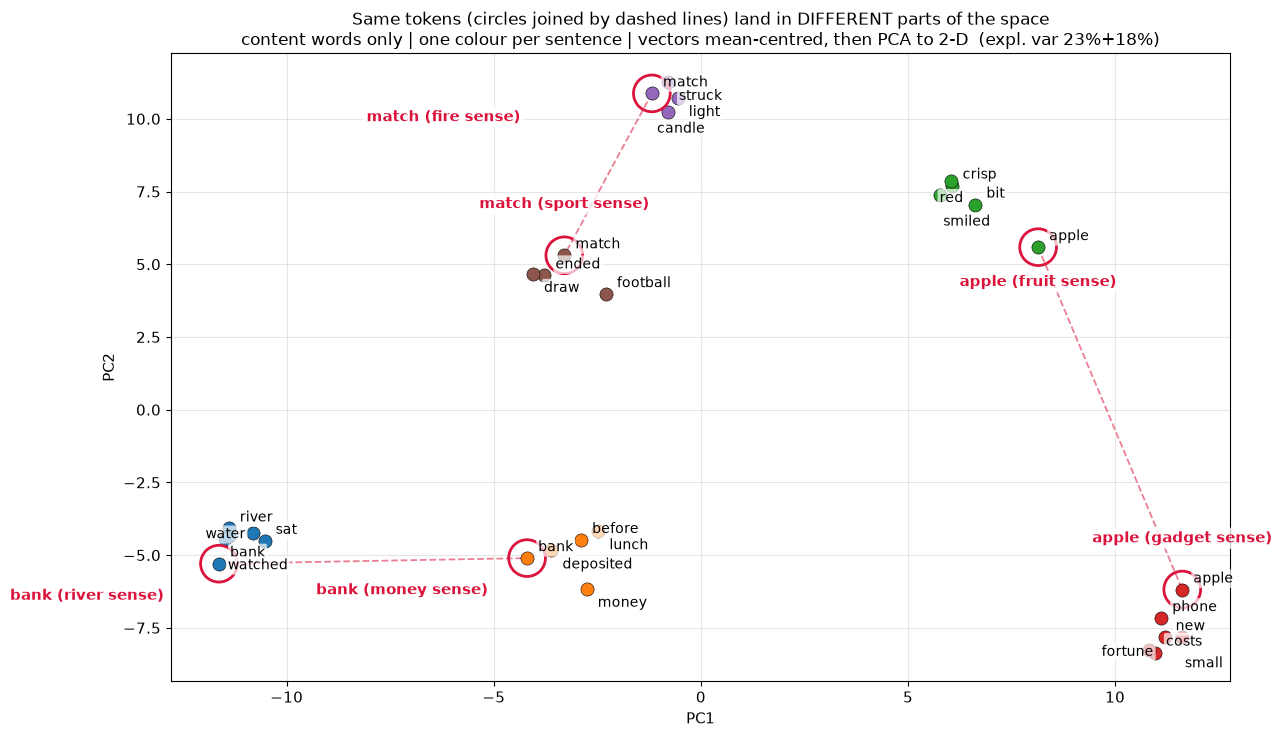

In [15]:
# ── Visual: the CONTENT words of the 6 sentences, projected to 2-D ──────────
# (function words dropped — they clump at the sentence centroid and only add clutter)
STOP = {"i", "on", "the", "and", "my", "at", "she", "into", "a", "to", "in", "he"}
SENSE = {"bank-A": "river sense",   "bank-B": "money sense",
         "apple-A": "fruit sense",  "apple-B": "gadget sense",
         "match-A": "fire sense",   "match-B": "sport sense"}

sel   = [k for k, (w, src) in enumerate(corpus_words) if w not in STOP]
kept  = [corpus_words[k] for k in sel]
pca   = PCA(n_components=2)
coords = pca.fit_transform(CORPUS[sel].numpy())          # centred vectors!
evr    = pca.explained_variance_ratio_

sent_color = {"bank-A": "#1f77b4", "bank-B": "#ff7f0e",
              "apple-A": "#2ca02c", "apple-B": "#d62728",
              "match-A": "#9467bd", "match-B": "#8c564b"}

fig, ax = plt.subplots(figsize=(13, 7.5))
amb_pts = {}
for (w, src), (x, y) in zip(kept, coords):
    ax.scatter(x, y, s=90, c=sent_color[src], edgecolors="k",
               linewidths=0.4, zorder=3)
    if w == src.split("-")[0]:                    # the ambiguous word of its sentence
        amb_pts[src] = (x, y)

# greedy, collision-free word labels: try candidate offsets, keep the first
# position whose box touches nothing already placed; drop the label if none fit.
OFFS = [(8, 5), (8, -13), (-8, 6), (-8, -15), (14, -4), (-34, -4), (2, 13), (2, -22)]
placed, dropped = [], []
fig.canvas.draw()
for (w, src), (x, y) in sorted(zip(kept, coords),
                               key=lambda t: -t[0][0].startswith(t[0][1].split("-")[0])):
    ok = False
    for off in OFFS:
        t = ax.annotate(w, (x, y), textcoords="offset points", xytext=off,
                        fontsize=10, zorder=5,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white",
                                  ec="none", alpha=0.7))
        bb = t.get_window_extent()
        if not any(bb.overlaps(p) for p in placed):
            placed.append(bb); ok = True
            break
        t.remove()
    if not ok:
        dropped.append(w)
if dropped:
    print("labels dropped as unplaceable:", dropped)

# dashed line = "these two points are the SAME token id, two contexts"
for amb in ("bank", "apple", "match"):
    (xa, ya), (xb, yb) = amb_pts[f"{amb}-A"], amb_pts[f"{amb}-B"]
    ax.plot([xa, xb], [ya, yb], ls="--", lw=1.3, color="crimson", alpha=0.55, zorder=2)

# place each sense label on the side where the sentence's cloud is NOT
CANDS = {"bank-A": [(-95, -26)], "bank-B": [(-90, -26)], "apple-A": [(0, -28)],
         "apple-B": [(0, 34)],    "match-A": [(0, -28), (-150, -20), (120, -20)],
         "match-B": [(0, 34)]}
for src_, (x, y) in amb_pts.items():
    ax.scatter(x, y, s=700, facecolors="none", edgecolors="crimson",
               linewidths=2, zorder=4)
    for off in CANDS[src_]:
        t = ax.annotate(f"{src_.split('-')[0]} ({SENSE[src_]})", (x, y),
                        textcoords="offset points", xytext=off, ha="center",
                        fontsize=11, color="crimson", fontweight="bold", zorder=6,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white",
                                  ec="none", alpha=0.75))
        bb = t.get_window_extent()
        if not any(bb.overlaps(p) for p in placed):
            placed.append(bb)
            break
        t.remove()

ax.set_title("Same tokens (circles joined by dashed lines) land in DIFFERENT parts of the space\n"
             "content words only | one colour per sentence | vectors mean-centred, then PCA to 2-D  "
             f"(expl. var {evr[0]:.0%}+{evr[1]:.0%})", fontsize=12)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()


**Static vs contextual — the one-line difference**

| | word2vec / FastText | BERT-style (BGE-M3) |
|---|---|---|
| What is a word's vector? | a row in a **lookup table**, frozen at training time | the **output of the network**, a function of the whole document |
| Two `bank`s in different contexts | literally the same numbers (cos = 1.00) | different numbers (centred cos ≈ 0.3) |
| Meaning selection | none — you get one blurred average of all senses | the neighbours (`river` vs `money`) pull the vector to the right sense |

> **Why this matters for everything below**: the "dense sentence vector" of
> Section 3 is just the **mean of these context-varying token vectors**; the
> sparse weight of Section 4 and the ColBERT vectors of Section 5 are projections
> of the same vectors. Contextualisation is the single ingredient that all three
> retrieval modes are built on.


---
## 3. Dense Sentence Embeddings

> **Dense embedding** = a single fixed-dim vector representing the *meaning* of the whole input.

For a **word**: word2vec already gives you this (300-dim, static).
For a **sentence**: BGE-M3 gives you a **1024-dim** vector computed by **mean-pooling contextual token representations** — each token already "knows" what its neighbours are.

### 3a. Encoding individual words


In [16]:
words = ["cat", "dog", "bird", "fish",
         "machine", "learning", "neural network",
         "apple", "bank"]

out_words = model.encode(words, max_length=512, return_dense=True)
W = out_words["dense_vecs"]
if isinstance(W, np.ndarray):
    W = torch.from_numpy(W.astype(np.float32)).float()

print(f"Dense shape: {tuple(W.shape)}    ← N words × 1024 dims")
print(f"  Each single word → one 1024-dim vector (subword tokens mean-pooled)")


Dense shape: (9, 1024)    ← N words × 1024 dims
  Each single word → one 1024-dim vector (subword tokens mean-pooled)


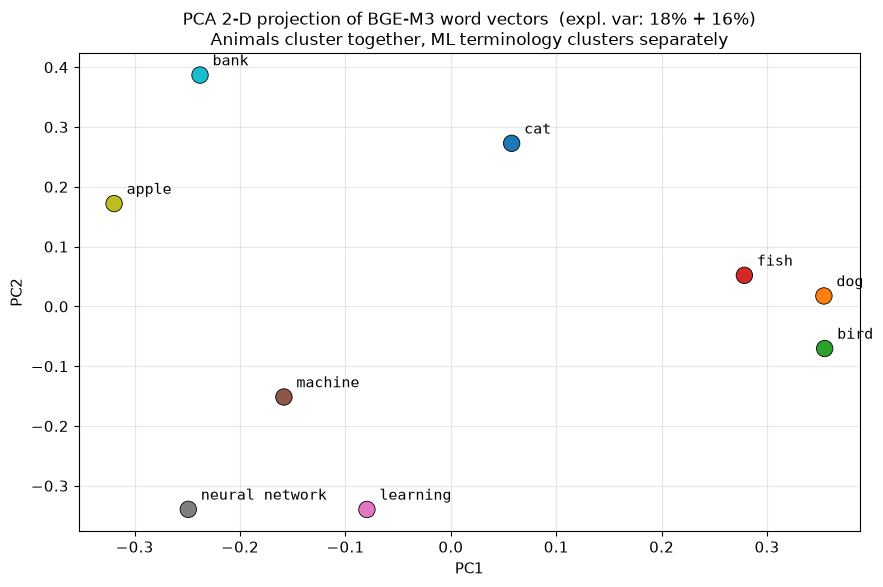

In [17]:
# ── PCA scatter ───────────────────────────────────────────────────
# PCA is used here instead of UMAP because numba (UMAP's dep)
# is incompatible with NumPy ≥ 2.5. The visual result is the same
# for this small word set.
pca    = PCA(n_components=2)
coords = pca.fit_transform(W.numpy())
evr    = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(words)))
ax.scatter(coords[:, 0], coords[:, 1], s=140, c=colors,
           edgecolors="k", linewidths=0.6, zorder=3)
for i, w in enumerate(words):
    ax.annotate(w, coords[i], textcoords="offset points",
                xytext=(9, 7), fontsize=11, fontname="monospace")
ax.set_title("PCA 2-D projection of BGE-M3 word vectors  "
             f"(expl. var: {evr[0]:.0%} + {evr[1]:.0%})\n"
             "Animals cluster together, ML terminology clusters separately", fontsize=12)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()


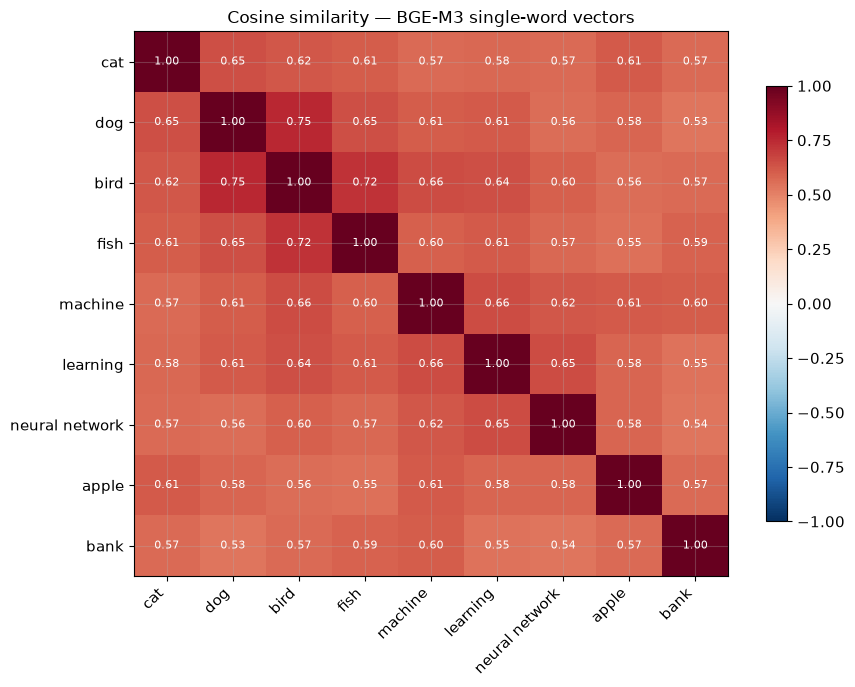

In [18]:
# ── Cosine similarity heatmap ────────────────────────────────────
W_n = W / W.norm(dim=-1, keepdim=True)
cos   = (W_n @ W_n.T).numpy()          # (N, N) similarity matrix

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cos, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha="right")
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{cos[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(cos[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Cosine similarity — BGE-M3 single-word vectors", fontsize=12)
plt.tight_layout()
plt.show()


**Reading the heatmap:**

| Pair | Similarity | Why |
|------|-----------|-----|
| `machine ↔ learning` | ≈ 0.65 | Semantically linked concepts (ML field) |
| `cat ↔ dog` | ≈ 0.60-0.65 | Same semantic category (animals) |
| `apple ↔ bank` | ≈ 0.50-0.55 | Unrelated but not fully orthogonal in 1024-d space |

> Even though each word is just **one subword token**, BGE-M3 runs a full
> transformer forward pass so each word is placed relative to the **entire model's
> learned geometry** — not just a bag-of-words average.


### 3b. Encoding sentences — where dense embeddings really shine


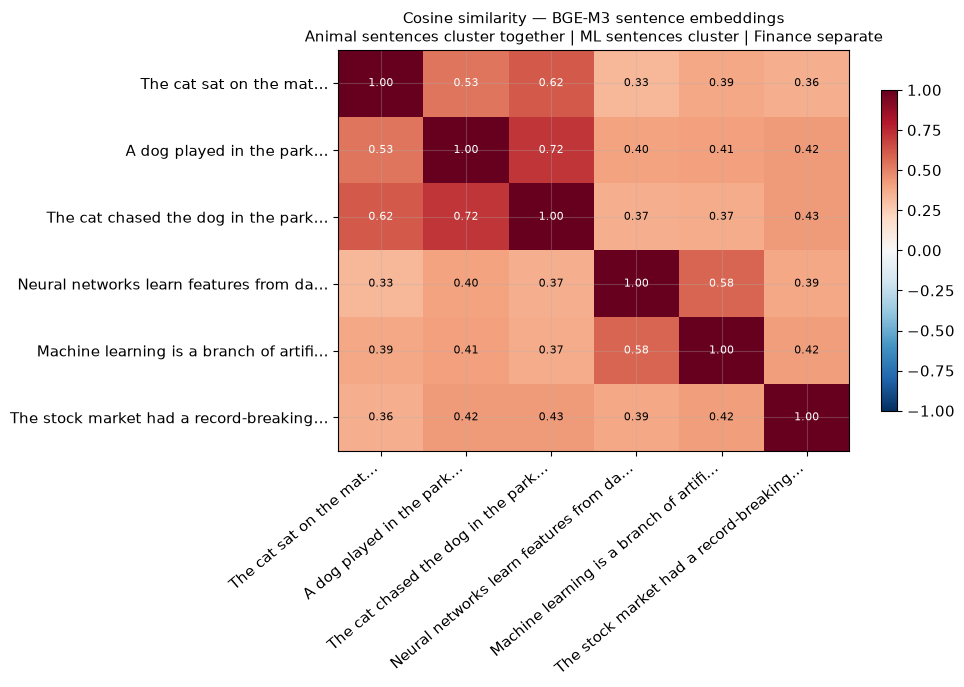

In [19]:
sentences = [
    "The cat sat on the mat",
    "A dog played in the park",
    "The cat chased the dog in the park",
    "Neural networks learn features from data",
    "Machine learning is a branch of artificial intelligence",
    "The stock market had a record-breaking day",
]

out_s = model.encode(sentences, max_length=8192, return_dense=True)
S = out_s["dense_vecs"]
if isinstance(S, np.ndarray):
    S = torch.from_numpy(S.astype(np.float32)).float()

S_n = S / S.norm(dim=-1, keepdim=True)
cos_s   = (S_n @ S_n.T).numpy()        # (N, N) similarity matrix
short = [s[:38] + "…" for s in sentences]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(cos_s, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(sentences)))
ax.set_xticklabels(short, rotation=40, ha="right")
ax.set_yticks(range(len(sentences)))
ax.set_yticklabels(short)
for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax.text(j, i, f"{cos_s[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(cos_s[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Cosine similarity — BGE-M3 sentence embeddings\n"
             "Animal sentences cluster together | ML sentences cluster | Finance separate", fontsize=11)
plt.tight_layout()
plt.show()


### 3c. Why this beats averaging word2vec vectors

```python
# word2vec approach (loses order and context):
# vec = np.mean([w2v.w[v] for v in sentence.split()])
#
# BGE-M3 approach (each token is contextualised first):
# vec = mean([transformer_h[i] for i in range(len(tokens))])
```

| Aspect | word2vec mean-pool | BGE-M3 dense |
|--------|-------------------|--------------|
| Word order | ❌ lost | ✅ preserved by attention |
| Disambiguation (`bank`) | ❌ always same | ✅ context-dependent |
| Negation ("not good") | ❌ ≈ "good" | ✅ partially captures |
| Cross-lingual | ❌ | ✅ 100+ languages |

> **Rule of thumb**: Any task where meaning > exact keywords → use dense embeddings.


---
## 4. Sparse Embeddings — Learned Per-Token Weights

> **Sparse embedding** = a very high-dim vector that is almost all zeros,
> with a learned scalar weight at each **vocab token position**.
> Think of it as **BM25, but learned with context**.

| | **BM25** | **BGE-M3 sparse** |
|---|---|---|
| Formula | `IDF × TF / (TF + k·(1−b+b·dl))` | Learned scalar per token |
| Trained? | No (heuristic) | ✔ Distilled from BM25 + dense signals |
| Context? | ❌ Per-word independent | ✅ Weight depends on neighbours |
| Dim | vocab size (~50k) | vocab size (~25k BPE tokens) |
| Speed | ⚡ Fastest | Fast (sparse-matrix multiply) |

### When to prefer sparse over dense?

- **Keyword-heavy queries**: SKUs, error codes, legal clause numbers
- **Rare terms** that dominate a document but get diluted in a dense vector
- **Hybrid signals**: `score = α·dense + (1−α)·sparse` (production default)


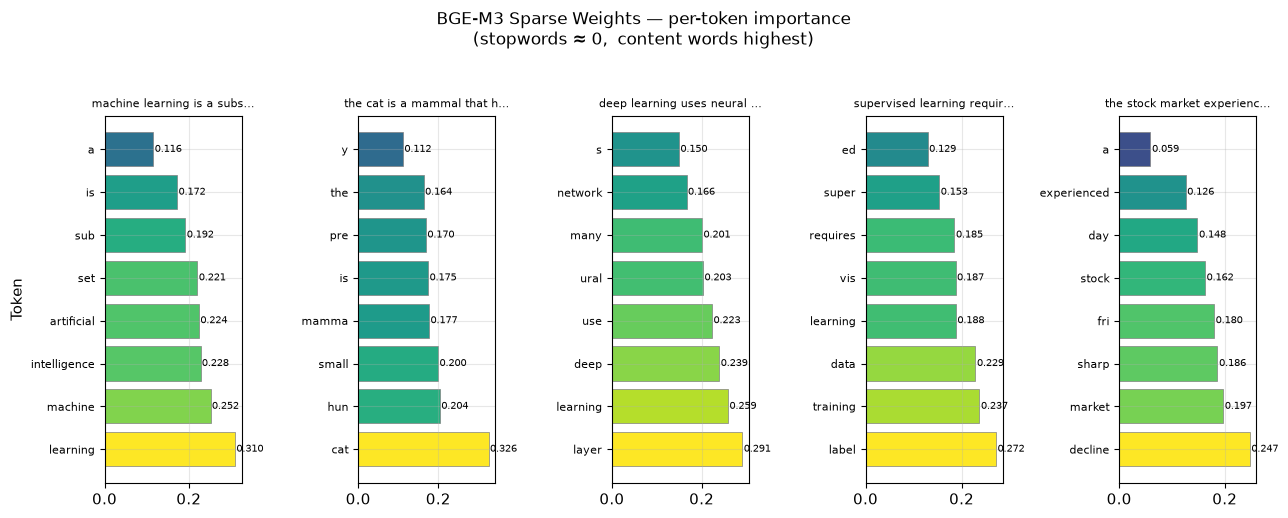

In [20]:
docs_sparse = [
    "machine learning is a subset of artificial intelligence",
    "the cat is a mammal that hunts small prey",
    "deep learning uses neural networks with many layers",
    "supervised learning requires labeled training data",
    "the stock market experienced a sharp decline on friday",
]

out_sp = model.encode(docs_sparse, max_length=8192, return_sparse=True)
lexical = out_sp["lexical_weights"]   # list of  {token_id: weight}

# ── Horizontal bar charts: top-8 tokens per doc ──────────────────
TOP_N = 8
fig, axes = plt.subplots(1, len(docs_sparse),
                         figsize=(2.6 * len(docs_sparse), 5), squeeze=False)

cmap = plt.cm.viridis
for i, (doc, lex) in enumerate(zip(docs_sparse, lexical)):
    top   = sorted(lex.items(), key=lambda x: -x[1])[:TOP_N]
    toks  = [model.tokenizer.decode([int(tid)]) for tid, _ in top]
    wts   = [float(w) for _, w in top]
    w_max = max(wts) if wts else 1

    ax = axes[0][i]
    short_doc = doc[:26] + "…"
    bars = ax.barh(range(len(toks))[::-1], wts,
                   color=[cmap(w / w_max) for w in wts],
                   edgecolor="grey", linewidth=0.5)
    ax.set_yticks(range(len(toks))[::-1])
    ax.set_yticklabels(toks, fontsize=8)
    ax.set_title(short_doc, fontsize=8, pad=6)
    ax.invert_yaxis()
    for bar, w in zip(bars, wts):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f"{w:.3f}", va="center", fontsize=7)

axes[0][0].set_ylabel("Token")
fig.suptitle("BGE-M3 Sparse Weights — per-token importance\n"
             "(stopwords ≈ 0,  content words highest)",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


> **Key observation**: `the`, `is`, `a` get near-zero weight.
> `learning`, `neural`, `cat` get the highest weights.
> BGE-M3 **learns** to suppress function words even when they're frequent — BM25 would penalise them mechanically but inconsistently.


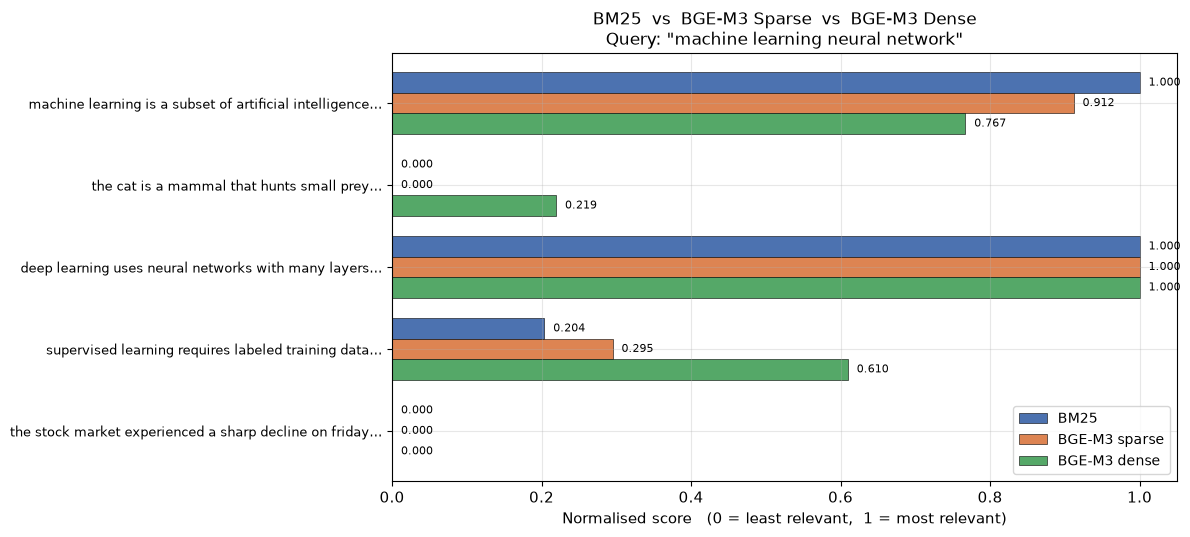

In [21]:
# ── BM25 vs BGE-sparse vs BGE-dense: head-to-head ────────────────
query = "machine learning neural network"

# 1) BM25
docs_tok    = [re.findall(r"\w+", d.lower()) for d in docs_sparse]
bm25        = BM25Okapi(docs_tok)
bm25_scores = bm25.get_scores(re.findall(r"\w+", query.lower()))

# 2) BGE-M3 sparse (dot product of shared token weights)
def sparse_dot(lex_a: dict, lex_b: dict) -> float:
    common = set(lex_a) & set(lex_b)
    return sum(float(lex_a[k]) * float(lex_b[k]) for k in common)

out_q      = model.encode([query],     max_length=8192, return_sparse=True, return_dense=True)
out_docs_a = model.encode(docs_sparse, max_length=8192, return_sparse=True, return_dense=True)

q_lex          = out_q["lexical_weights"][0]
bge_sparse_raw = np.array([sparse_dot(q_lex, d) for d in out_docs_a["lexical_weights"]])

# 3) BGE-M3 dense (cosine)
qd = out_q["dense_vecs"]
if isinstance(qd, np.ndarray): qd = torch.from_numpy(qd.astype(np.float32)).float()
D  = out_docs_a["dense_vecs"]
if isinstance(D, np.ndarray):  D  = torch.from_numpy(D.astype(np.float32)).float()
bge_dense_raw = cosine_similarity(qd, D).squeeze(0).numpy()

def norm(s):
    s = np.asarray(s, dtype=np.float64)
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0.0

bm25_n = norm(bm25_scores);  spar_n = norm(bge_sparse_raw);  dens_n = norm(bge_dense_raw)

# ── Grouped bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))
y      = np.arange(len(docs_sparse))
bar_h  = 0.25
labels = [d[:55] + "…" for d in docs_sparse]

b1 = ax.barh(y - bar_h, bm25_n, height=bar_h,
             label="BM25",          color="#4C72B0", edgecolor="k", linewidth=0.4)
b2 = ax.barh(y,         spar_n, height=bar_h,
             label="BGE-M3 sparse", color="#DD8452", edgecolor="k", linewidth=0.4)
b3 = ax.barh(y + bar_h, dens_n, height=bar_h,
             label="BGE-M3 dense",  color="#55A868", edgecolor="k", linewidth=0.4)

for bars in (b1, b2, b3):
    for b in bars:
        ax.text(b.get_width() + 0.012, b.get_y() + b.get_height()/2,
                f"{b.get_width():.3f}", va="center", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Normalised score   (0 = least relevant,  1 = most relevant)")
ax.set_title(f'BM25  vs  BGE-M3 Sparse  vs  BGE-M3 Dense\nQuery: "{query}"', fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Reading the chart:**

All three methods rank `machine learning is a subset…` first — expected.

The difference appears in ranking #2:
- **BM25** gives high score to `"deep learning uses neural networks…"` (shares `learning`, `neural`) but very low to `"supervised learning requires labeled data"` (only shares `learning`)
- **BGE-dense** gives moderate score to the supervised-learning doc — it captures that `"supervised learning"` IS a kind of `"machine learning"`
- **BGE-sparse** sits in between — it's more context-aware than BM25 but less than dense

> **Production recommendation**: combine dense + sparse with `α≈0.5-0.7` for RAG pipelines.


---
## 5. ColBERT — Token-Level Multi-Vector Retrieval

> **ColBERT** (Khattab & Zaharia, 2020 — [arxiv.org/abs/2004.14255](https://arxiv.org/abs/2004.14255)):
> instead of one vector per document, each **token** gets its own vector.
> At query time, align each query token to its best-matching doc token, then sum.

```
score(query, doc) = Σᵢ  maxⱼ  ( qᵢ · dⱼ / |qᵢ| |dⱼ| )
                   ──over query tokens    best-matching doc token
```

| Dense (mean-pooled) | ColBERT (token-level) |
|---|---|
| `cat+sat+on+mat` → all averaged together | `cat` aligns to `cat`, `sat` aligns to `sat`, … |
| Fine-grained matches get diluted | Each query token finds its best doc-token partner |
| Fast | Slower (N_tok × M_tok lookups per pair) |

**Use ColBERT when:**
- You're re-ranking top-100 candidates (not first-stage retrieval over millions)
- Documents are long and keyword positions matter
- You need highest accuracy for a final ranking step


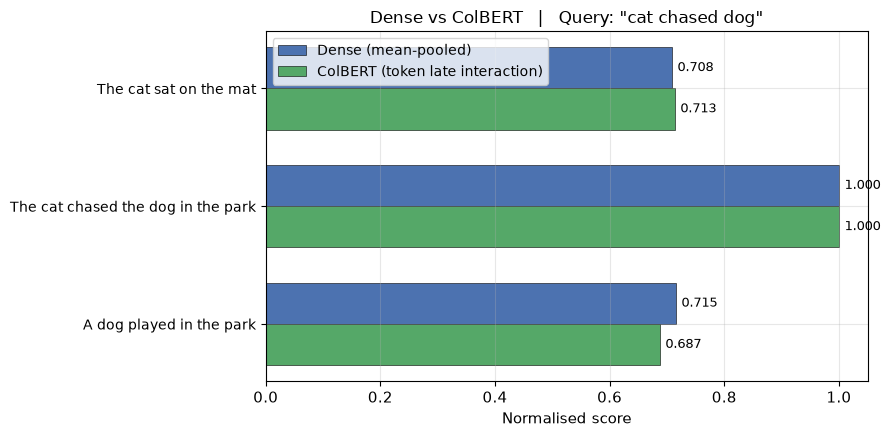

In [22]:
query_c = "cat chased dog"
docs_c  = [
    "The cat sat on the mat",
    "The cat chased the dog in the park",
    "A dog played in the park",
]

out_cq = model.encode([query_c], max_length=8192, return_colbert_vecs=True)
out_cd = model.encode(docs_c,   max_length=8192, return_colbert_vecs=True)

q_vecs = out_cq["colbert_vecs"][0]   # (Q_len, D)
d_vecs = out_cd["colbert_vecs"]      # list of (Doc_len, D)

def colbert_score_np(q, d):
    """Late interaction (numpy): q=(Q,D), d=(N,D)  →  Σᵢ maxⱼ cos(qᵢ, dⱼ)"""
    qn = q / (np.linalg.norm(q, axis=-1, keepdims=True) + 1e-9)
    dn = d / (np.linalg.norm(d, axis=-1, keepdims=True) + 1e-9)
    sim       = qn @ dn.T          # (Q, N)
    return (sim.max(axis=1)).sum()

colbert_scores = [colbert_score_np(q_vecs, dv) for dv in d_vecs]

# Dense scores for comparison
out_qd2 = model.encode([query_c], max_length=8192, return_dense=True)
out_dd2 = model.encode(docs_c,   max_length=8192, return_dense=True)
qd2 = out_qd2["dense_vecs"]
if isinstance(qd2, np.ndarray): qd2 = torch.from_numpy(qd2.astype(np.float32)).float()
D2  = out_dd2["dense_vecs"]
if isinstance(D2, np.ndarray):  D2  = torch.from_numpy(D2.astype(np.float32)).float()
d_dense = cosine_similarity(qd2, D2).numpy()   # (N,)  or (1, N)
dense_scores = d_dense.flatten()

# ── Chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
y          = np.arange(len(docs_c))
bar_h      = 0.35
d_norm     = dense_scores / dense_scores.max()
c_norm     = np.array(colbert_scores) / max(colbert_scores)

b1 = ax.barh(y - bar_h/2, d_norm, height=bar_h,
             label="Dense (mean-pooled)",
             color="#4C72B0", edgecolor="k", linewidth=0.4)
b2 = ax.barh(y + bar_h/2, c_norm, height=bar_h,
             label="ColBERT (token late interaction)",
             color="#55A868", edgecolor="k", linewidth=0.4)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2,
                f"{b.get_width():.3f}", va="center", fontsize=9)

ax.set_yticks(y);  ax.set_yticklabels(docs_c, fontsize=10)
ax.set_xlabel("Normalised score")
ax.set_title(f'Dense vs ColBERT   |   Query: "{query_c}"', fontsize=12)
ax.legend(fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


> ColBERT gives a **higher relative score** to `"The cat chased the dog in the park"`
> because it aligns `chased`→`chased`, `cat`→`cat`, `dog`→`dog` **token-by-token**.
> Dense averaging dilutes those strong matches with `sat`, `mat`, `park`.


---
## 5b. The Simple RAG Default — sentence-transformers, no server

> **The most-used minimal stack for RAG retrieval**: the `sentence-transformers`
> package + `all-MiniLM-L6-v2`. One `pip install`, one import, in-process —
> the model weights (~90 MB) download once like any other dependency.
> **No server, no deployment** (unlike Ollama, which *is* a server), no GPU needed.

```
pip install sentence-transformers
```

| | all-MiniLM-L6-v2 | BGE-M3 (this notebook) |
|---|---|---|
| Size / params | ~90 MB / 22 M | ~2.3 GB / 570 M |
| Vector dim | 384 | 1024 |
| Max input | **256 word-pieces** | 8192 tokens |
| Hardware | laptop CPU, milliseconds | GPU preferred |
| Languages | mostly English | 100+ |
| Modes | dense only | dense + sparse + ColBERT |

```python
# the whole API:
vec = model.encode(texts, normalize_embeddings=True)   # → np.ndarray, one row per text
```

> **Recall what `encode()` just did under the hood** (Section 2b → pooling): run the
> transformer, **mean-pool** the contextual token vectors, **L2-normalize**. Exactly
> the "centroid of the token crowd" — contrastively trained so the centroid ranks well.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16330.74it/s]


query vector: (1, 384)   passages: (4, 384)

Query: "how much do cats sleep?"
  #1  cos=+0.791  Cats sleep 12 to 16 hours a day in short naps.
  #2  cos=+0.446  Kittens drink their mother's milk for about twelve weeks.
  #3  cos=+0.067  Python is a popular programming language.
  #4  cos=-0.015  The stock market fell sharply on inflation fears.


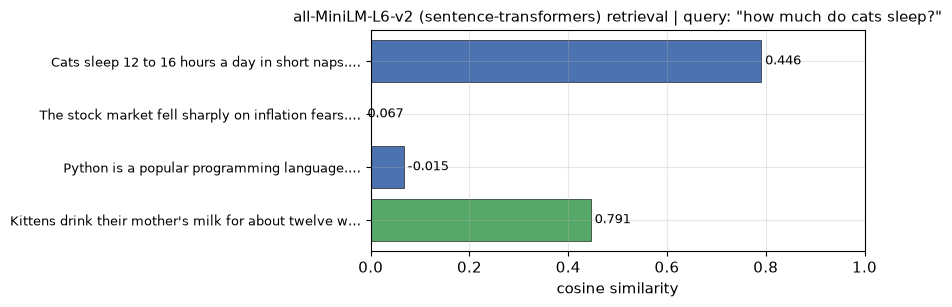

In [24]:
# ── Minimal RAG retrieval: query → ranked passages, one package, no server ───
from sentence_transformers import SentenceTransformer

st = SentenceTransformer("all-MiniLM-L6-v2")     # downloads once, then fully offline

passages = [
    "Cats sleep 12 to 16 hours a day in short naps.",
    "The stock market fell sharply on inflation fears.",
    "Python is a popular programming language.",
    "Kittens drink their mother's milk for about twelve weeks.",
]
query = "how much do cats sleep?"

q_vec = st.encode([query],  normalize_embeddings=True)     # (1, 384)
p_vec = st.encode(passages, normalize_embeddings=True)     # (4, 384)

print(f"query vector: {q_vec.shape}   passages: {p_vec.shape}")
sims = p_vec @ q_vec[0]                                    # normalized → dot = cosine
order = np.argsort(sims)[::-1]
print(f'\nQuery: "{query}"')
for rank, i in enumerate(order, 1):
    print(f"  #{rank}  cos={sims[i]:+.3f}  {passages[i]}")

# ── same ranking as a bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.2))
b = ax.barh(range(len(passages))[::-1], sims,
            color=["#55A868" if r == 0 else "#4C72B0" for r in range(len(sims))][::-1],
            edgecolor="k", linewidth=0.4)
ax.set_yticks(range(len(passages))[::-1])
ax.set_yticklabels([p[:52] + "…" for p in passages], fontsize=9)
for bar, s in zip(b, sims[::-1]):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f"{s:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1); ax.set_xlabel("cosine similarity")
ax.set_title(f'all-MiniLM-L6-v2 (sentence-transformers) retrieval | query: "{query}"',
             fontsize=11)
plt.tight_layout()
plt.show()


> **When the simple default is enough**: prototypes, English docs under ~200 words,
> CPU-only environments, "good embeddings fast". **When to graduate** to BGE-M3:
> longer documents (256-word-piece cap!), multilingual, hybrid sparse+dense needs.
>
> The same **decision guide** below applies — MiniLM is just the cheapest entry
> point to the "dense" row of it.

---
## 6. Decision Guide — Which Method for Which Task?

| Task | What you need | Best method |
|------|--------------|-------------|
| **Exact keyword / ID search** (SKUs, error codes) | Rare terms must match exactly | **BM25** or **BGE-sparse** |
| **Semantic similarity** (paraphrase, dedup, clustering) | Meaning, not surface words | **BGE-M3 dense** |
| **RAG — first-stage retrieval** (millions of docs → top-100) | Fast + semantic | **BM25 + BGE-dense** hybrid |
| **RAG — re-ranking** (top-100 → top-10) | Highest accuracy, slower | **BGE-ColBERT** or `bge-reranker-v2` |
| **Cross-lingual search** (query EN, doc JA) | Multilingual training | **BGE-M3 dense** (100+ languages) |
| **Sentence classification** (sentiment, topic) | Embedding + linear probe | **BGE-M3 dense** + sklearn |
| **OOV / subword features** (rare words, agglutinative langs) | Subword morphology | **FastText** (word-level) still valid |

### Hybrid scoring (the production recipe)

```python
def hybrid_score(dense_score: float, sparse_score: float, alpha: float = 0.5) -> float:
    """
    alpha = 1.0  →  pure dense (semantic)
    alpha = 0.0  →  pure sparse (keyword)
    alpha = 0.5  →  balanced (good default for RAG)

    Tune by domain:
      Legal / medical (rare terms critical):  alpha = 0.3
      Customer support (paraphrase matters):  alpha = 0.7
    """
    return alpha * dense_score + (1 - alpha) * sparse_score
```


---
## 7. word2vec → BGE-M3: Mental Model

```
word2vec / FastText               BGE-M3
─────────────────                 ──────────────────────────────────────
word       →  1 static vec     │
sentence   →  mean(word vecs)  │  sentence →  1 dense vec   (contextual)
no context ❌                   │             →  sparse weights (learned BM25)
                                │             →  ColBERT vecs  (token-level)
monolingual usually ❌            │         100+ languages  ✔
no doc-level signal ❌            │         8192-token window  ✔
free & tiny ✔                   │         ~2 GB, GPU preferred
```

**Still worth knowing word2vec / FastText for:**
- Classic analogy tasks (`king − man + woman`)
- Low-resource or CPU-only settings (400 MB model vs 2 GB)
- Feature extraction for downstream sequence models
- Subword / morphology features as input features

**When you must move past them:**
- Any task where **sentence meaning** matters (RAG, QA, clustering)
- Any task with **paraphrase or word-order sensitivity**
- **Cross-lingual** retrieval


---
## 8. References

### Papers

| Paper | Link | Why it matters |
|-------|------|----------------|
| **Mikolov et al., 2013** — *Efficient Estimation of Word Representations in Vector Space* | [arxiv.org/abs/1301.3781](https://arxiv.org/abs/1301.3781) | word2vec — the baseline |
| **Pérez et al., 2019** — *FastText.zip: Compressing Text Completion Models* | [arxiv.org/abs/1907.05286](https://arxiv.org/abs/1907.05286) | FastText subword approach |
| **Roberts et al., 2020** — *RoBERTa* | [arxiv.org/abs/1907.11692](https://arxiv.org/abs/1907.11692) | BERT-style contextual embeddings |
| **Khattab & Zaharia, 2020** — *ColBERT: Efficient and Effective Passage Search via Contextualised Late Interaction* | [arxiv.org/abs/2004.14255](https://arxiv.org/abs/2004.14255) | Token-level late interaction (ColBERT mode) |
| **Chen et al., 2023** — *BGE M3-Embedding: Multi-Lingual, Multi-Functionality, Multi-Granularity Text Embeddings Through Self-Knowledge Distillation* | [arxiv.org/abs/2402.03216](https://arxiv.org/abs/2402.03216) | **BGE-M3** — dense + sparse + ColBERT in one model |

### Tutorials & Docs

- 📖 [FlagEmbedding GitHub](https://github.com/FlagOpen/FlagEmbedding) — official code repo, BGE-M3 examples for all three modes
- 🔬 [BAAI/bge-m3 on HuggingFace](https://huggingface.co/BAAI/bge-m3) — model card with benchmark tables
- 📝 [BM25 Explained — DataAspirant](https://dataaspirant.com/blog/bm25-explained/) — TF-IDF → BM25 step by step in Python
- 📝 [Prisren — BGE-M3 multilingual embeddings](https://pristren.com/blog/bge-m3-embeddings-multilingual/) — hybrid scoring recipes + cost analysis
- 📝 [Axiom — Dense vs Lexical vs Multi-Vector retrieval](https://axiomlogica.com/ai-ml/bge-m3-bge-reranker-benchmarks-dense-lexical-multi-vector-retrieval) — practical comparison with benchmarks

> **Bottom line**: For any modern RAG or semantic-search system in 2025+, you need at minimum
> **BM25 + a dense embedding model**. Add **ColBERT** (or a reranker) for the final ranking pass.
> Word2vec/FastText are still useful for lightweight word-level tasks but are no longer sufficient for sentence-level retrieval.
